# Plot the results of this r / m test experiment

### Helper Functions

In [9]:
import numpy as np
import os
import matplotlib.pyplot as plt

import json
import subprocess


os.chdir('/Users/milesgantcher/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven')

In [10]:
def ordered_permutations(arr, n):
    if n == 0:
        return [[]]

    result = []
    smaller_perms = ordered_permutations(arr, n - 1)

    for x in arr:
        for p in smaller_perms:
            result.append([x] + p)

    return result

In [11]:
def read_final_loss(metadata_path):
    with open(metadata_path, "r") as f:
        for line in f:
            if line.startswith("final_loss ="):
                return float(line.split("=", 1)[1].strip())
    raise ValueError("final_loss not found")

In [17]:
def load_many_final_theta_jls(path_by_key, julia_exe="julia"):
    import json
    import subprocess
    import numpy as np

    keys = list(path_by_key.keys())
    paths = [path_by_key[key] for key in keys]

    julia_code = r"""
    using Serialization

    function print_num_array(xs)
        print("[")
        for (i, x) in enumerate(xs)
            i > 1 && print(",")
            print(x)
        end
        print("]")
    end

    print("[")
    for (i, path) in enumerate(ARGS)
        i > 1 && print(",")
        history = deserialize(path)
        print_num_array(collect(history[end].θ))
    end
    print("]")
    """

    result = subprocess.run(
        [julia_exe, "-e", julia_code, *paths],
        check=True,
        capture_output=True,
        text=True,
    )

    theta_arrays = json.loads(result.stdout)

    return {
        key: np.asarray(theta)
        for key, theta in zip(keys, theta_arrays)
    }

### Final Loss Calculation

In [18]:
names = {}
md_path = {}
final_losses = {}

j = 0
arr = [1,2,3,4,5,10,15,20,30]
L = len(arr)
perms = [[m,r] for m in arr for r in arr]
for m,r in perms:
    names[(m,r)] = f"Research_Code/Optimization/Data/ROM_M_R_HPO/ROM_short_training_param_sweep_{str(j)}_m-{str(m)}__r-{str(r)}"
    md_path[(m,r)] = names[(m,r)] + "/metadata.txt"
    final_losses[(m,r)] = read_final_loss(md_path[(m,r)])
    j += 1
    
param_paths = {(m, r): names[(m, r)] + "/parameter_history.jls"for m, r in perms}

theta_finals = load_many_final_theta_jls(param_paths)

In [20]:
theta_finals[1,1]

array([ 1.99758839,  3.00889785,  1.71614473, -1.22166973,  3.04852304,
       -2.01841312, -1.03537036, -0.61916834, -0.12010487, -0.89739683,
        0.58271515, -0.77133379, -0.78118116, -1.06183394,  0.03163395,
       -0.54641079,  0.14542163, -0.03699065, -0.13623057, -0.96691016,
        0.27340896,  0.42642791, -0.67450439, -0.93777333,  1.18508279,
        0.39570817, -0.25069979,  0.47528596, -0.56776348,  0.16698286,
       -0.45261298, -0.52658051, -0.29283125, -1.15756511,  0.99058593,
        0.08302808,  0.77691194,  0.95443684,  0.97024827, -0.24486875,
        1.03563801, -0.85042241,  1.44412422,  0.40888599, -1.63422706,
       -0.17269628,  0.07488256,  0.85691892,  0.99543173, -0.67007655,
       -0.44913764,  0.34282907, -0.99841763, -0.20518692, -0.39495926,
        0.15687066, -0.60315889,  0.13285418,  0.81418239,  1.51013364,
       -2.00901205,  0.72759349,  0.01539353, -0.14290746, -0.93703005,
       -0.21438873, -0.7373465 , -0.6259463 , -0.4137371 , -0.68

### Final Loss vs m,r

In [60]:
import matplotlib.pyplot as plt
r_curves = [[] for _ in range(L)]
for rdx,r in enumerate(arr):
    for mdx,m in enumerate(arr):
        r_curves[rdx].append(final_losses[m,r])

m_curves = [[] for _ in range(L)]
for mdx,m in enumerate(arr):
    for rdx,r in enumerate(arr):
        m_curves[mdx].append(final_losses[m,r])

# r_curves = np.asarray(r_curves)


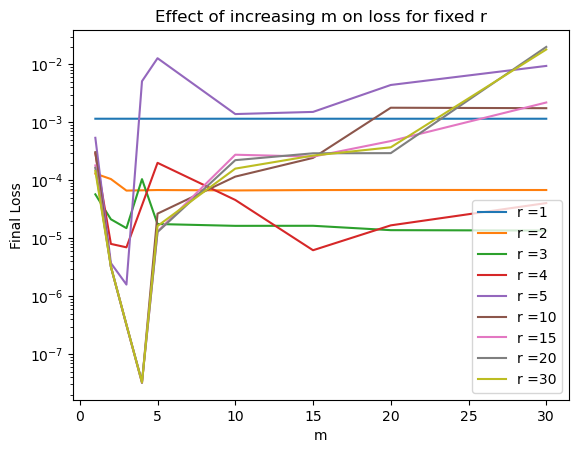

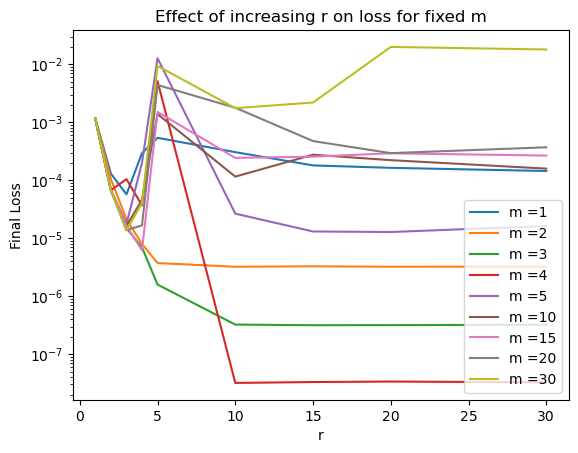

In [61]:
for rdx,curve in enumerate(r_curves):
    plt.semilogy(arr,curve, label = f"r ={arr[rdx]}")
plt.legend()
plt.title('Effect of increasing m on loss for fixed r')
plt.xlabel("m")
plt.ylabel("Final Loss")
plt.show()

for mdx,curve in enumerate(m_curves):
    plt.semilogy(arr,curve, label = f"m ={arr[mdx]}")
plt.legend()
plt.title('Effect of increasing r on loss for fixed m')
plt.xlabel("r")
plt.ylabel("Final Loss")
plt.show()

### Final Loss vs Final L2 Error of f(u)
- Here's an interesting question! Is final loss a good measure for learning? In FOM vs ROM, it doesn't seem to be. 